In [2]:
import pandas as pd


In [3]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [4]:
import seaborn as sns

In [5]:
df  = pd.read_csv("house_price.csv")

In [6]:
df.head()

,Area,Price
0,500,25.0
1,600,30.0
2,700,35.0
3,800,40.0
4,900,45.0


In [7]:
df.shape

(21, 2)

Text(0, 0.5, 'Area')

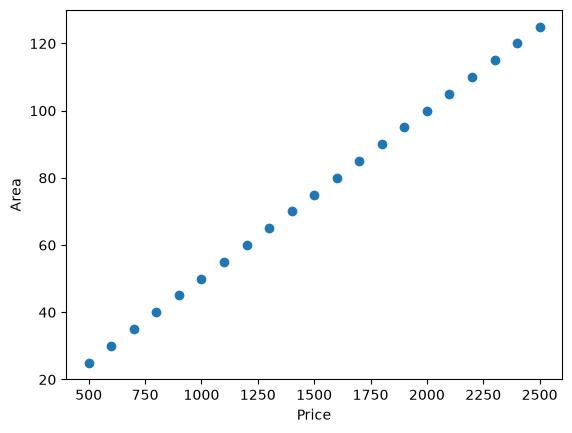

In [8]:
plt.scatter(df['Area'],df['Price'])
plt.xlabel("Price")
plt.ylabel("Area")

In [9]:
df.corr()

,Area,Price
Area,1.0,1.0
Price,1.0,1.0


In [11]:
## Independent and dependent features
X=df[['Area']] ### independent features should be data frame or 2 dimesnionalarray
y=df['Price'] ## this variiable can be in series or 1d array

In [12]:
## Train Test Split
from sklearn.model_selection import train_test_split

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
X_train.shape

(16, 1)

In [15]:
X_test.shape

(5, 1)

In [16]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [18]:
X_test = scaler.transform(X_test)

In [19]:
X_test

array([[-1.87835761],
       [ 1.14479783],
       [ 0.78913249],
       [-1.70052493],
       [-0.45569622]])

In [20]:
##Apply simple linear regression
from sklearn.linear_model import LinearRegression

In [21]:
model = LinearRegression(n_jobs=-1)

In [23]:
model.fit(X_train,y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[28.12]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,77.81
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.]


Price=b0​+b1​(Area)


In [24]:
print("Coefficient or slope:",model.coef_)
print("Intercept:",model.intercept_)

Coefficient or slope: [28.1163181]
Intercept: 77.8125


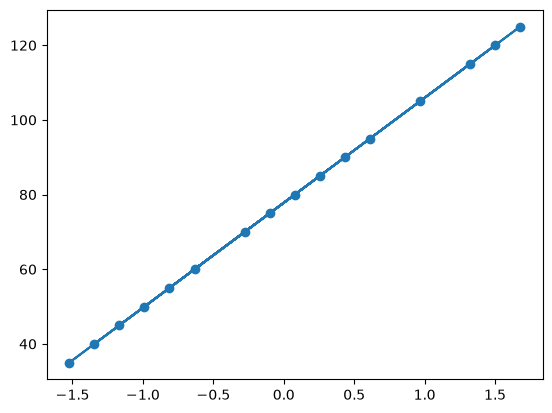

In [25]:
plt.scatter(X_train,y_train)
plt.plot(X_train,model.predict(X_train))

In [26]:
y_pred = model.predict(X_test)

In [27]:
print("Actual:", y_test.values[:5])
print("Predicted:", y_pred[:5])

Actual: [ 25. 110. 100.  30.  65.]
Predicted: [ 25. 110. 100.  30.  65.]


In [28]:
from sklearn.metrics import mean_absolute_error

In [29]:
mae = mean_absolute_error(y_test, y_pred)

In [30]:
print("Mean Absolute Error:", mae)

Mean Absolute Error: 5.684341886080802e-15


In [31]:
from sklearn.metrics import mean_squared_error

In [32]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 8.077935669463161e-29


In [33]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 8.987733679556355e-15


In [34]:
from sklearn.metrics import r2_score

In [35]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 1.0


In [36]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R2 Score:", adjusted_r2)

Adjusted R2 Score: 1.0


In [37]:
## Prediction For new data
model.predict(scaler.transform([[4000]]))

c:\Users\karan\OneDrive\Desktop\LinearRegression\House-price-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([200.])

In [38]:
new_data = pd.DataFrame({
    'Area': [4000]
})

prediction = model.predict(scaler.transform(new_data))

print("Predicted Price:", prediction[0])

Predicted Price: 200.00000000000003
